# Airline Tweet Sentiment with Naive Bayes

This notebook keeps only the positive and negative airline tweets, removes links and @mentions, and turns the text into word counts with `CountVectorizer`. A Multinomial Naive Bayes model then gets 90.65% accuracy, but recall on positive tweets is only 0.6173, because 80% of the tweets are negative and positive ones are often missed.

## 1. Imports and loading the data

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

import glob, os

def find_file(name):
    # on Kaggle the attached dataset lives under /kaggle/input
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else name   # fallback: same folder (for running locally)

tweets_df = pd.read_csv(find_file('Tweets.csv'))
print("Shape:", tweets_df.shape)
print(tweets_df['airline_sentiment'].value_counts())
print((tweets_df['airline_sentiment'].value_counts(normalize=True) * 100).round(2))

# keep positive and negative only
tweets_df = tweets_df[tweets_df['airline_sentiment'].isin(['positive', 'negative'])].copy()
print("\nRows after dropping neutral tweets:", len(tweets_df))
print(tweets_df['airline_sentiment'].value_counts())
print((tweets_df['airline_sentiment'].value_counts(normalize=True) * 100).round(2))

Shape: (14640, 15)
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64

Rows after dropping neutral tweets: 11541
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


The full data has 14,640 tweets. After dropping the 3,099 neutral tweets, 11,541 remain: 9,178 negative (79.53%) and 2,363 positive (20.47%).

## 2. Cleaning and vectorization

In [2]:
# negative = 0, positive = 1
tweets_df['label'] = tweets_df['airline_sentiment'].map({'negative': 0, 'positive': 1})

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove links
    text = re.sub(r'@\w+', ' ', text)              # remove @mentions
    text = text.replace('#', '')                    # keep the hashtag word, drop the #
    text = text.replace("'", '')                    # dont, isnt, cant
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove punctuation, digits, emojis
    return ' '.join(text.split())

tweets_df['clean_text'] = tweets_df['text'].apply(clean_tweet)
print(tweets_df[['text', 'clean_text']].head())

Xb = tweets_df['clean_text']
yb = tweets_df['label']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42, stratify=yb
)

# fit the vectorizer on the training tweets only
vectorizer_b = CountVectorizer()
Xb_train_vec = vectorizer_b.fit_transform(Xb_train)
Xb_test_vec = vectorizer_b.transform(Xb_test)

print("\nVocabulary size:", len(vectorizer_b.get_feature_names_out()))
print("Training data shape:", Xb_train_vec.shape)
print("Testing data shape:", Xb_test_vec.shape)

                                                text  \
1  @VirginAmerica plus you've added commercials t...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   
5  @VirginAmerica seriously would pay $30 a fligh...   
6  @VirginAmerica yes, nearly every time I fly VX...   

                                          clean_text  
1  plus youve added commercials to the experience...  
3  its really aggressive to blast obnoxious enter...  
4            and its a really big bad thing about it  
5  seriously would pay a flight for seats that di...  
6  yes nearly every time i fly vx this ear worm w...  

Vocabulary size: 8813
Training data shape: (9232, 8813)
Testing data shape: (2309, 8813)


I removed links and @mentions because the mention is usually just the airline name and carries no sentiment. The vectorizer learned 8,813 words from the training tweets only.

## 3. Naive Bayes model and evaluation

Accuracy : 0.9065
Precision: 0.8930
Recall   : 0.6173
F1-score : 0.7300

Confusion matrix:
 [[1801   35]
 [ 181  292]]


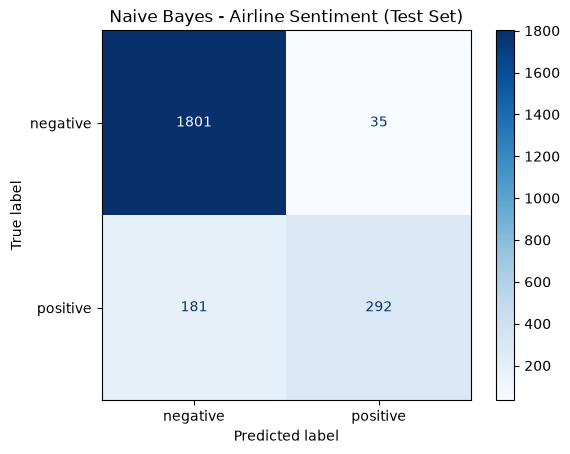

In [3]:
nb_tweet = MultinomialNB()
nb_tweet.fit(Xb_train_vec, yb_train)

yb_pred = nb_tweet.predict(Xb_test_vec)

print(f"Accuracy : {accuracy_score(yb_test, yb_pred):.4f}")
print(f"Precision: {precision_score(yb_test, yb_pred):.4f}")
print(f"Recall   : {recall_score(yb_test, yb_pred):.4f}")
print(f"F1-score : {f1_score(yb_test, yb_pred):.4f}")

cm = confusion_matrix(yb_test, yb_pred)
print("\nConfusion matrix:\n", cm)

ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Naive Bayes - Airline Sentiment (Test Set)')
plt.show()

The model found 292 positive tweets but missed 181, and only 35 negative tweets were wrongly called positive. Accuracy looks good, but recall of 0.6173 shows the model struggles with positive tweets. Naive Bayes counts each word on its own, so tweets that mix a complaint with a thank you are often called negative.